In [2]:
import os, json, time
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, pipeline, EarlyStoppingCallback, TrainerCallback
)
from peft import get_peft_model, LoraConfig, TaskType
from captum.attr import Saliency
from termcolor import colored

In [3]:
# Prepare data
df = pd.read_csv("parking_dataset.csv")
df["text"] = df["sign"].str.strip() + ". " + df["input_time"].str.strip() + ". " + df["question"].str.strip()
df["label"] = df["label"].astype(int)
class_0 = df[df["label"] == 0].sample(n=837, random_state=42)
class_1 = df[df["label"] == 1].sample(n=837, random_state=42)
balanced_df = pd.concat([class_0, class_1]).sample(frac=1, random_state=42)

def save_jsonl(df, path): 
    with open(path, "w") as f: 
        for _, row in df.iterrows(): 
            f.write(json.dumps({"text": row["text"], "label": row["label"]}) + "\n")

train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df["label"], random_state=42)
save_jsonl(test_df, "llama_test.jsonl")



 Training with 500 samples


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at NousResearch/Meta-Llama-3-8B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/bitsandbytes/nn/modules.py:457: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc,Auprc
1,4.229700,0.729993,0.731343,0.888889,0.526946,0.661654,0.893392,0.876951
2,2.873000,0.580680,0.850746,0.892617,0.796407,0.841772,0.915384,0.922892
3,2.349300,0.422753,0.862687,0.862275,0.862275,0.862275,0.944753,0.944642


Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
LlamaForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`



Computing saliency for first test example...

Token Saliency (normalized):

<|begin_of_text|>NO 0.56
PARKING         0.25
8AM-8:30AM      0.07
EXCEPT          0.09
SUNDAY          0.04
AND             0.03
NO              0.03
PARKING         0.09
WEDNESDAY       0.03
8:30AM-10AM.    0.05
It              0.15
is              0.16
currently       0.42
WED             0.21
8:20AM.         0.13
Can             0.14
I               0.20
park            0.15
here?           0.20


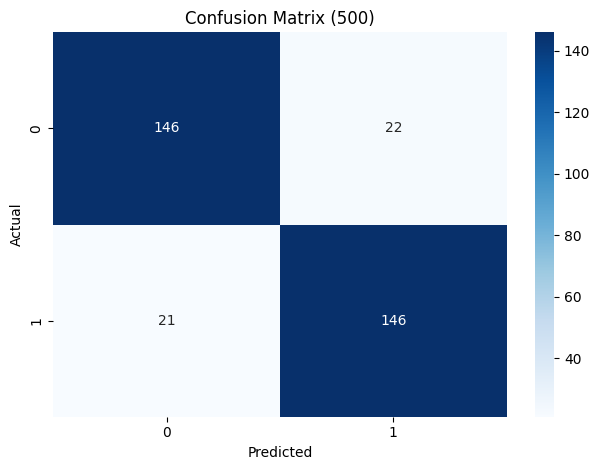


 Training with 1000 samples


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/335 [00:00<?, ? examples/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at NousResearch/Meta-Llama-3-8B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc,Auprc
1,38.366500,3.099006,0.785075,0.880000,0.658683,0.753425,0.893784,0.864066
2,21.728300,1.967092,0.859701,0.934783,0.772455,0.845902,0.936217,0.931625
3,57.596900,5.990119,0.874627,0.874251,0.874251,0.874251,0.918894,0.877243


Device set to use cuda:0



Computing saliency for first test example...

Token Saliency (normalized):

<|begin_of_text|>NO 0.59
PARKING         0.26
8AM-8:30AM      0.06
EXCEPT          0.14
SUNDAY          0.05
AND             0.04
NO              0.03
PARKING         0.09
WEDNESDAY       0.05
8:30AM-10AM.    0.09
It              0.18
is              0.20
currently       0.39
WED             0.27
8:20AM.         0.17
Can             0.13
I               0.18
park            0.12
here?           0.25


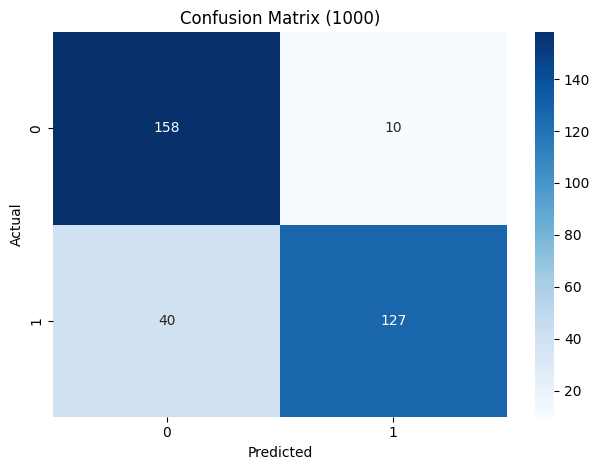


 Training with 1339 samples


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1339 [00:00<?, ? examples/s]

Map:   0%|          | 0/335 [00:00<?, ? examples/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at NousResearch/Meta-Llama-3-8B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc,Auprc
1,2.821000,0.437057,0.883582,0.944444,0.814371,0.874598,0.958690,0.952920
2,1.887400,0.332868,0.928358,0.923077,0.934132,0.928571,0.982214,0.974121
3,0.539400,0.282023,0.943284,0.956790,0.928144,0.942249,0.988167,0.987332


Device set to use cuda:0



Computing saliency for first test example...

Token Saliency (normalized):

<|begin_of_text|>NO 0.57
PARKING         0.25
8AM-8:30AM      0.14
EXCEPT          0.11
SUNDAY          0.03
AND             0.06
NO              0.04
PARKING         0.13
WEDNESDAY       0.05
8:30AM-10AM.    0.12
It              0.13
is              0.19
currently       0.30
WED             0.42
8:20AM.         0.24
Can             0.09
I               0.17
park            0.12
here?           0.25


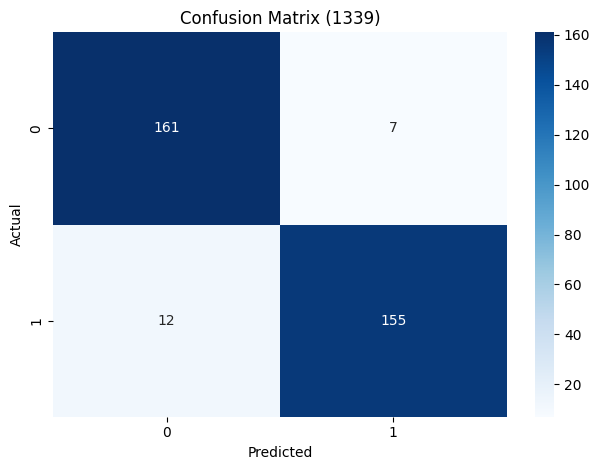

In [4]:
# ---------------------- Epoch Logger ----------------------
class EpochMetricsLogger(TrainerCallback):
    def __init__(self, output_dir):
        self.output_dir = output_dir
        self.metrics = []

    def on_evaluate(self, args, state, control, metrics, **kwargs):
        metrics["epoch"] = int(state.epoch)
        self.metrics.append(metrics)

    def on_train_end(self, args, state, control, **kwargs):
        df = pd.DataFrame(self.metrics)
        df.to_csv(os.path.join(self.output_dir, "epoch_metrics.csv"), index=False)
        
# Loop through training sizes
for size in [500, 1000, len(train_df)]:
    print(f"\n Training with {size} samples")
    subset = train_df.iloc[:size]
    save_jsonl(subset, f"llama_train_{size}.jsonl")

    dataset = load_dataset("json", data_files={"train": f"llama_train_{size}.jsonl", "test": "llama_test.jsonl"})
    model_name = "NousResearch/Meta-Llama-3-8B"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token

    def tokenize(example): 
        return tokenizer(example["text"], padding="max_length", truncation=True, max_length=256)

    dataset = dataset.map(tokenize, batched=True).remove_columns(["text"])
    dataset.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, load_in_4bit=True,
        torch_dtype=torch.float16, device_map="auto"
    )

    model.config.pad_token_id = tokenizer.pad_token_id
    
    model = get_peft_model(model, LoraConfig(
        r=64, lora_alpha=16, target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05, bias="none", task_type=TaskType.SEQ_CLS
    ))

    output_dir = f"llm_lora_output_{size}"
    os.makedirs(output_dir, exist_ok=True)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()  # Probabilities for class 1
        preds = logits.argmax(axis=1)
        
        return {
            "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds),
            "recall": recall_score(labels, preds),
            "f1": f1_score(labels, preds),
            "auroc": roc_auc_score(labels, probs),
            "auprc": average_precision_score(labels, probs)
        }

    training_args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        bf16=True,
        warmup_ratio=0.1,
        report_to="none",
        resume_from_checkpoint=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["test"],
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=2),
            EpochMetricsLogger(output_dir=output_dir)
        ]
    )

    start = time.time()
    trainer.train()
    end = time.time()

    model.save_pretrained(f"{output_dir}/final_model")
    tokenizer.save_pretrained(f"{output_dir}/final_model")

    # Inference
    pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)
    test_texts = test_df["text"].tolist()
    y_true = test_df["label"].tolist()
    y_pred, y_prob, times = [], [], []

    for text in test_texts:
        t0 = time.time()
        out = pipe(text, truncation=True, max_length=256)[0]
        t1 = time.time()
        times.append(t1 - t0)
        label = 1 if out["label"] == "LABEL_1" else 0
        score = out["score"]
        y_pred.append(label)
        y_prob.append(score if label == 1 else 1 - score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # ========== SALIENCY VISUALIZATION ==========
    print("\nComputing saliency for first test example...")

    text = test_texts[0]
    example_input = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=256)
    input_ids = example_input["input_ids"].to(model.device)
    attention_mask = example_input["attention_mask"].to(model.device)

    embedding_layer = model.get_input_embeddings()
    input_embeddings = embedding_layer(input_ids)
    input_embeddings.requires_grad_()

    def forward_func_embeds(embeds):
        return model(inputs_embeds=embeds, attention_mask=attention_mask).logits

    saliency = Saliency(forward_func_embeds)
    attributions = saliency.attribute(input_embeddings, target=1)
    scores = attributions[0].detach().cpu().norm(dim=1).numpy()
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    filtered_tokens, filtered_scores = [], []
    for tok, tok_id, score in zip(tokens, input_ids[0], scores):
        if tok_id != tokenizer.pad_token_id:
            filtered_tokens.append(tok)
            filtered_scores.append(score)

    def merge_subwords(tokens, scores):
        words, word_scores = [], []
        current_word, current_scores = "", []
        for tok, score in zip(tokens, scores):
            if tok.startswith("Ġ") or tok.startswith("▁"):
                if current_word:
                    words.append(current_word)
                    word_scores.append(np.mean(current_scores))
                current_word = tok[1:]
                current_scores = [score]
            else:
                current_word += tok
                current_scores.append(score)
        if current_word:
            words.append(current_word)
            word_scores.append(np.mean(current_scores))
        return words, word_scores

    merged_tokens, merged_scores = merge_subwords(filtered_tokens, filtered_scores)

    def show_colored_saliency(tokens, scores):
        print("\nToken Saliency (normalized):\n")
        for tok, score in zip(tokens, scores):
            bg = "on_red" if score > 0.5 else "on_white"
            print(colored(f"{tok:15}", "grey", bg), f"{score:.2f}")

    show_colored_saliency(merged_tokens, merged_scores)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({size})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"confusion_llama_{size}.png")
    plt.close()

    metrics = {
        "size": size,
        "model": "LLaMA-3 LoRA",
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "specificity": tn / (tn + fp),
        "sensitivity": tp / (tp + fn),
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "false_positives": fp,
        "false_negatives": fn,
        "avg_latency_sec": round(sum(times) / len(times), 3),
        "train_time_min": round((end - start) / 60, 2),
        "gpu_memory_GB": round(torch.cuda.max_memory_allocated() / 1e9, 2),
        "tokens": sum(len(tokenizer.encode(x)) for x in test_texts)
    }

    pd.DataFrame([metrics]).to_csv(f"llama_results_{size}.csv", index=False)